In [188]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#### setting col unnamed 0 as index by using index_col = 0 

In [189]:
# Load the Dataset

df = pd.read_csv(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\Linear_regression_4\dataset\Salary_dataset.csv', index_col=0)

In [190]:
# Undetstand the Dataset Structure

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 720.0 bytes


In [191]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [192]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


In [193]:
df.shape

(30, 2)

In [194]:
# Check for Missing Values

df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

In [195]:
# Check for Duplicates

df.duplicated().sum()

0

<Axes: xlabel='Salary'>

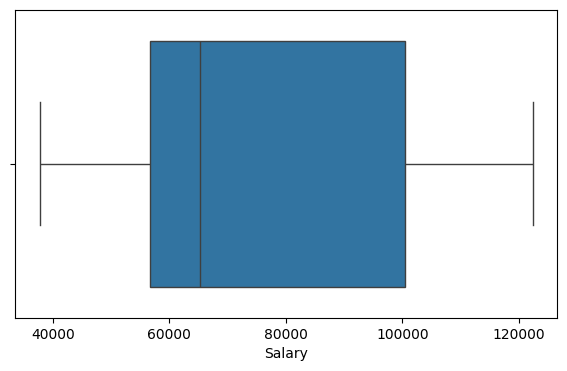

In [197]:
# Check Outliers

plt.figure(figsize = (7, 4))
sns.boxplot(df['Salary'], orient = 'h')

<Axes: xlabel='YearsExperience'>

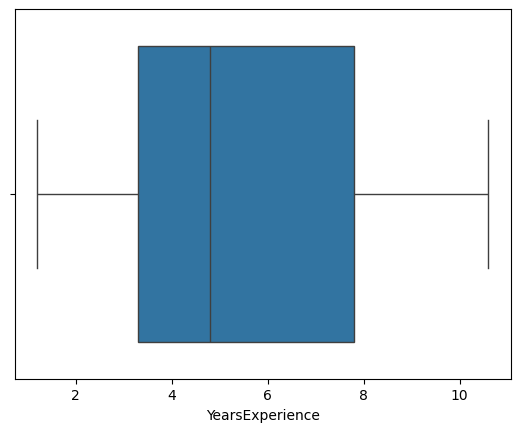

In [198]:
sns.boxplot(df['YearsExperience'], orient = 'h')

In [199]:
# Split the data into Features (X) and Target (y)

X = df[['YearsExperience']].values
y = df['Salary'].values



In [200]:
print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (30, 1)
Shape of y:  (30,)


In [201]:
# Reshaping X and y
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)
print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (30, 1)
Shape of y:  (30, 1)


In [ ]:
class UnivariateLinearRegressor:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta = None
        self.MSE_loss_history = []
        self.theta_history = []
        
    def MSE_loss(self, y_pred, y):
        m = y.shape[0]
        loss = (1 / (2 * m)) * np.sum((y_pred - y)**2)
        return loss
    
    def gradient_descent(self, X, y, y_pred, theta):
        m = y.shape[0]
        # Compute gradients first
        gradient_0 = np.sum(y_pred - y) / m
        gradient_1 = np.sum(np.dot((y_pred - y).T, X[:, 1])) / m

        # Update parameters
        theta[0] = theta[0] - self.learning_rate * gradient_0
        theta[1] = theta[1] - self.learning_rate * gradient_1
        
        return theta
    
    def fit(self, X: np.ndarray, y:np.ndarray) -> np.ndarray:
        """
        Reshape the input X and train the model

        Args:
            X (np.ndarray): Input feature matrix of dimension (n_samples, n_features)
            y (np.ndarray): Label matrix of dimension (n_samples, 1)

        Returns:
            np.ndarray: Parameter: theta matrix of dimension (n_features+1, 1)
        """
        # Add new dimension to X
        new_dimension = np.ones((X.shape[0], 1))  # Adds a bias (intercept) column of ones 
        X = np.hstack((new_dimension, X))          #      → converts X from shape (m, 1) to (m, 2)

        # Initialize theta
        self.theta = np.zeros((X.shape[1], 1))   # Initializes theta (parameters) as a column vector of zeros: [θ0, θ1]
        
        # Training loop
        for i in range(self.n_iters):
            y_pred = np.dot(X, self.theta)
            # compute loss
            loss = self.MSE_loss(y_pred, y)  # Predicts values for each sample using current theta
            self.MSE_loss_history.append(loss)
            self.theta_history.append(self.theta)
            
            
            if i % 100 == 0:
                print(f"Iteration {i}: MSE Loss = {loss}")
            
            # use gradient descent
            self.theta = self.gradient_descent(X, y, y_pred, self.theta)  # update parameters using gradient descent
        
        return self.theta
    
    def predict(self, X: np.ndarray, theta: np.ndarray) -> np.ndarray:
        # This function assumes that X has been normalized
        new_dimension = np.ones((X.shape[0], 1))
        X = np.hstack((new_dimension, X))
        predictions = np.dot(X, theta)
        
        return predictions

In [ ]:
# Mean Normalization and Feature scaling
X_mean = np.mean(X)
X_std = np.std(X)
X = (X - X_mean) / X_std


y_mean = np.mean(y)   # for custom LR scale y for faster convergence
y_std = np.std(y)
y = (y - y_mean) / y_std


In [204]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [205]:
myModel = UnivariateLinearRegressor(learning_rate=0.01, n_iters=300)
theta = myModel.fit(X_train, y_train)


Iteration 0: MSE Loss = 0.5282397699049977
Iteration 100: MSE Loss = 0.07788890461697734
Iteration 200: MSE Loss = 0.025595945294015227


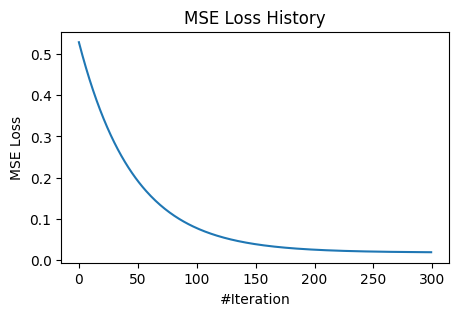

In [206]:
# Plotting Learning Curve
loss_history = myModel.MSE_loss_history
plt.figure(figsize=(5, 3))
sns.lineplot(loss_history)
plt.title("MSE Loss History")
plt.xlabel("#Iteration")
plt.ylabel("MSE Loss")
plt.show()

In [207]:
predictions = myModel.predict(X_test, theta)
print("Shape of y:", y_test.shape)
print("Shape of predictions:", predictions.shape)


Shape of y: (6, 1)
Shape of predictions: (6, 1)


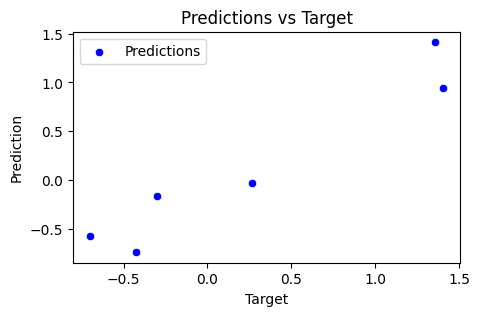

In [208]:
# Plotting predictions vs target

plt.figure(figsize=(5, 3))
sns.scatterplot(x=y_test.flatten(), y=predictions.flatten() , color='blue', label='Predictions')
plt.title("Predictions vs Target")
plt.xlabel("Target")
plt.ylabel("Prediction")
plt.show()

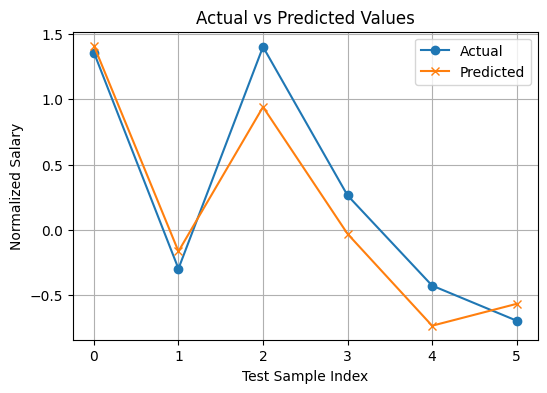

In [ ]:
# Predictions vs Actual - Line Plot
plt.figure(figsize=(6,4))
plt.plot(range(len(y_test)), y_test.flatten(), label='Actual', marker='o')
plt.plot(range(len(y_test)), predictions.flatten(), label='Predicted', marker='x')
plt.title("Actual vs Predicted Values")
plt.xlabel("Test Sample Index")
plt.ylabel("Normalized Salary")
plt.legend()
plt.grid(True)
plt.show()

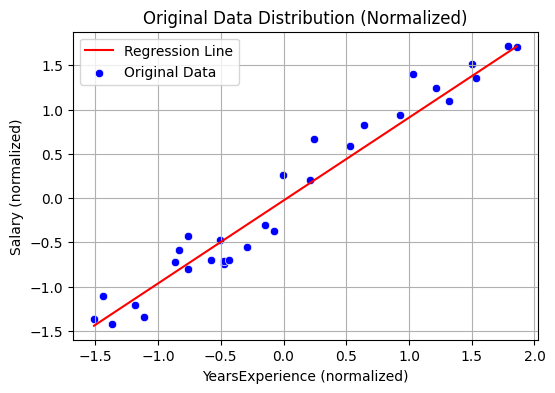

In [ ]:
#  Original Data Distribution with Regression Line
plt.figure(figsize=(6,4))
x_vals = np.linspace(min(X.flatten()), max(X.flatten()), 100).reshape(-1,1)
y_vals = myModel.predict(x_vals, theta)
plt.plot(x_vals, y_vals, color='red', label='Regression Line')
sns.scatterplot(x=X.flatten(), y=y.flatten(), color='blue', label='Original Data')
plt.title("Original Data Distribution (Normalized)")
plt.xlabel("YearsExperience (normalized)")
plt.ylabel("Salary (normalized)")
plt.legend()
plt.grid(True)
plt.show()

# Evaluation Metrics

Let:

- `y_true` = actual values  
- `y_pred` = predicted values

---

## 1️ Mean Absolute Error (MAE)

**Formula:**

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

**Explanation:**

- MAE measures the average absolute difference between the actual and predicted values.
- It tells us how far predictions are from actual values **on average**.
- Lower MAE is better.

---

## 2️ Mean Squared Error (MSE)

**Formula:**

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**Explanation:**

- MSE penalizes larger errors more than MAE.
- Squaring the errors emphasizes **larger mistakes**.
- Commonly used in training regression models.

---

## 3️ Root Mean Squared Error (RMSE)

**Formula:**

$$
\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

**Explanation:**

- RMSE is the square root of MSE.
- Has the **same unit** as the target variable.
- Easier to interpret than MSE.

---

## 4️ R² Score (Coefficient of Determination)

**Formula:**

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

**Explanation:**

- Measures the proportion of variance explained by the model.
- Values range from:
  - **1** (perfect fit)
  - **0** (no improvement over mean)
  - **< 0** (worse than a horizontal line at the mean)
- Higher R² means a better fit.

---


In [211]:

# Evaluation Metrics
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

# Compute and Print Metrics
mae_score = mae(y_test, predictions)
mse_score = mse(y_test, predictions)
rmse_score = rmse(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae_score)
print("MSE:", mse_score)
print("RMSE:", rmse_score)
print("R² Score:", r2)


MAE: 0.22972459104372947
MSE: 0.07194066775323232
RMSE: 0.26821757539958546
R² Score: 0.8976796063714245


#### Next task


In [212]:
# Fit the Linear Regression Model

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [213]:
# Extract the coefficients

print('Intercept:', model.intercept_)
print('Coefficient:', model.coef_[0])

Intercept: [-0.02261456]
Coefficient: [0.97553493]


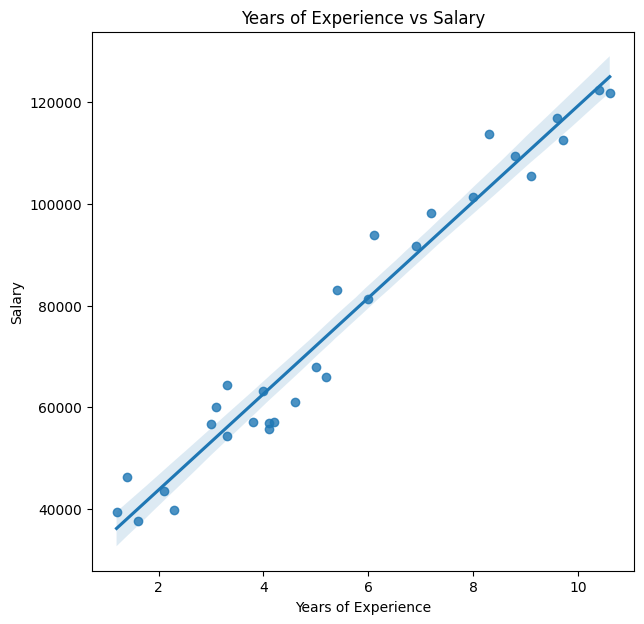

In [215]:
# Linearity

plt.figure(figsize = (7, 7))
sns.regplot(x = 'YearsExperience', y = 'Salary', data = df)
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.show()

In [216]:
# Evaluate the Model

y_test_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

R2: 0.9024461774180499
MAE: 0.23323200281725331
MSE: 0.06858932896507032
RMSE: 0.26189564518156905


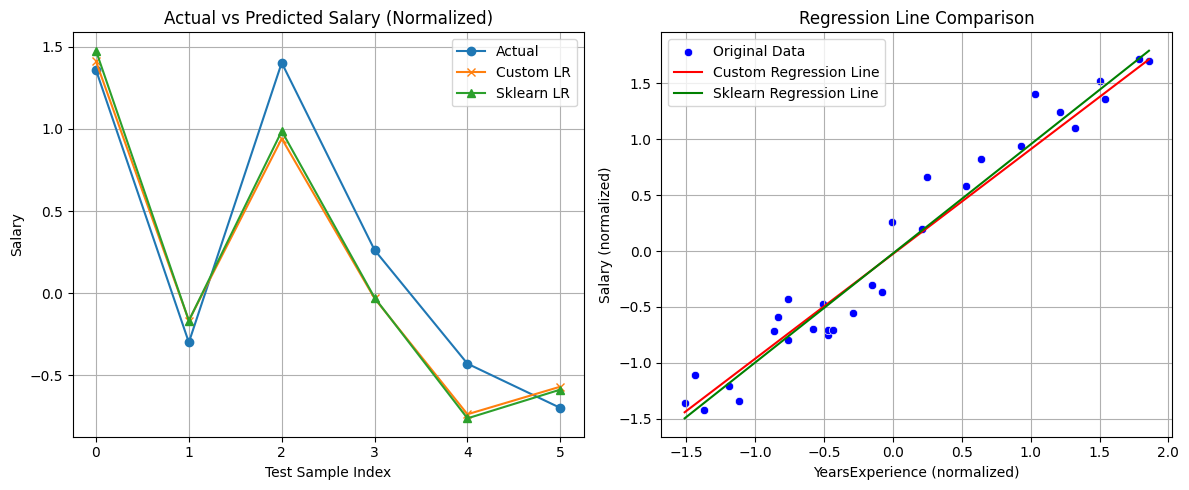

In [219]:
# Predictions using your model
predictions_custom = myModel.predict(X_test, theta)

# Predictions using sklearn model
predictions_sklearn = model.predict(X_test)

# Plot 1: Actual vs Predicted
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(len(y_test)), y_test.flatten(), label='Actual', marker='o')
plt.plot(range(len(y_test)), predictions_custom.flatten(), label='Custom LR', marker='x')
plt.plot(range(len(y_test)), predictions_sklearn.flatten(), label='Sklearn LR', marker='^')
plt.title("Actual vs Predicted Salary (Normalized)")
plt.xlabel("Test Sample Index")
plt.ylabel("Salary")
plt.legend()
plt.grid(True)

# Plot 2: Regression Line
plt.subplot(1, 2, 2)
x_vals = np.linspace(min(X.flatten()), max(X.flatten()), 100).reshape(-1, 1)
y_custom = myModel.predict(x_vals, theta)
y_sklearn = model.predict(x_vals)

sns.scatterplot(x=X.flatten(), y=y.flatten(), color='blue', label='Original Data')
plt.plot(x_vals, y_custom, label='Custom Regression Line', color='red')
plt.plot(x_vals, y_sklearn, label='Sklearn Regression Line', color='green')
plt.title("Regression Line Comparison")
plt.xlabel("YearsExperience (normalized)")
plt.ylabel("Salary (normalized)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


 ### Note: Reason for the Difference Between Custom and Sklearn Linear Regression Models
The small difference in the predictions and regression lines between the custom gradient descent-based linear regression model and scikit-learn’s LinearRegression model is primarily due to the difference in how the model parameters (θ) are optimized:

### Reason:
#### Optimization Method:

- Your custom model uses Gradient Descent, an iterative optimization method that gradually adjusts the model parameters to minimize the loss.

- sklearn.LinearRegression uses a closed-form solution (Normal Equation), which directly computes the optimal parameters without iteration.

#### Iteration Limitation:

- Since gradient descent depends on the number of iterations and learning rate, it might stop before reaching the exact global minimum, especially if:

- Learning rate is too low or too high

- Number of iterations is too small